<a href="https://colab.research.google.com/github/yoh6ly/Yohaly/blob/main/taller_svm_arboles_desde_cero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SVM lineal — accuracy: 0.986013986013986


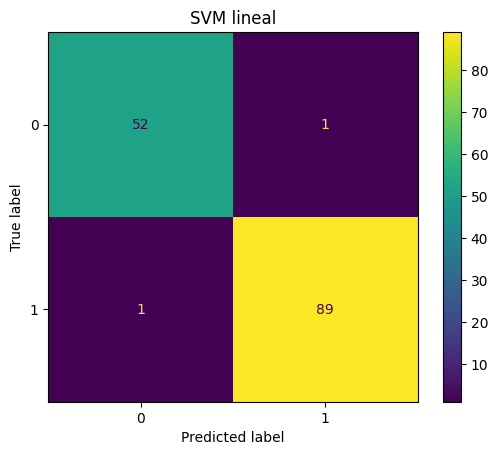

SVM RBF — accuracy: 0.9790209790209791


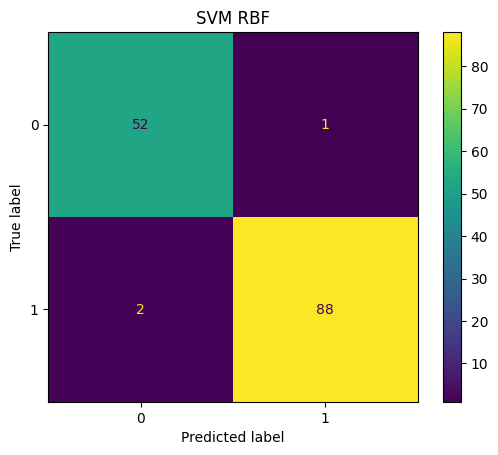

Árbol — accuracy: 0.9230769230769231


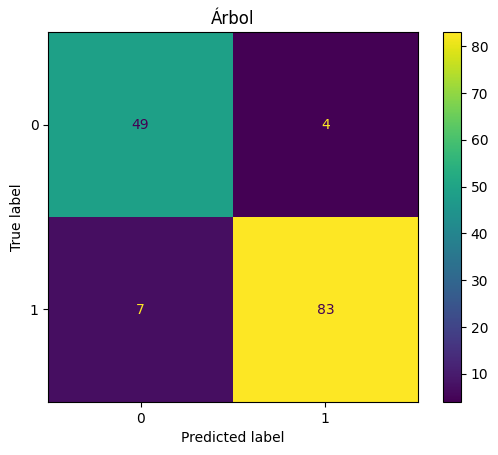

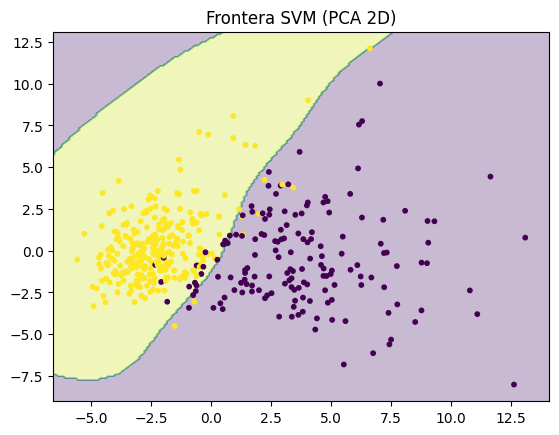

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
np.random.seed(42)

# Opción A (realista, más dimensiones):
data = load_breast_cancer(); X, y = data.data, data.target

# Opción B (2D para fronteras):
# X, y = make_moons(n_samples=800, noise=0.25, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)

svm_lin = SVC(kernel='linear', probability=True, random_state=42)
svm_lin.fit(X_tr_s, y_tr)
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, probability=True, random_state=42)
svm_rbf.fit(X_tr_s, y_tr)
tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree.fit(X_tr, y_tr)

for name, model, Xte in [
    ('SVM lineal', svm_lin, X_te_s),
    ('SVM RBF', svm_rbf, X_te_s),
    ('Árbol', tree, X_te)
]:
    y_pred = model.predict(Xte)
    acc = accuracy_score(y_te, y_pred)
    print(name, '— accuracy:', acc)
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
    plt.title(name); plt.show()

if X_tr.shape[1] > 2:
    pca = PCA(n_components=2).fit(X_tr_s)
    Xtr2 = pca.transform(X_tr_s); Xte2 = pca.transform(X_te_s)
    svm_2d = SVC(kernel='rbf', gamma='scale', C=1.0).fit(Xtr2, y_tr)
    xx, yy = np.meshgrid(np.linspace(Xtr2[:,0].min()-1, Xtr2[:,0].max()+1, 200),
                         np.linspace(Xtr2[:,1].min()-1, Xtr2[:,1].max()+1, 200))
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(Xtr2[:,0], Xtr2[:,1], c=y_tr, s=10)
    plt.title('Frontera SVM (PCA 2D)'); plt.show()